# Data Transformation

This notebook covers:

1. Data loading and inspection
2. Exploratory Data Analysis (EDA)
3. Standardization using StandardScaler
4. Normalization using MinMaxScaler
5. Label Encoding
6. One-Hot Encoding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and Inspect the Dataset

In [ ]:
df = pd.read_csv("Sales_cars_seats.csv")
df.head()

,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,1,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,2,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,3,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,4,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,5,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [3]:
df.dtypes

Unnamed: 0       int64
Sales          float64
CompPrice        int64
Income           int64
Advertising      int64
Population       int64
Price            int64
ShelveLoc       object
Age              int64
Education        int64
Urban           object
US              object
dtype: object

In [4]:
df.shape

(400, 12)

In [5]:
df.columns

Index(['Unnamed: 0', 'Sales', 'CompPrice', 'Income', 'Advertising',
       'Population', 'Price', 'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')

# 2. Exploratory Data Analysis (EDA)

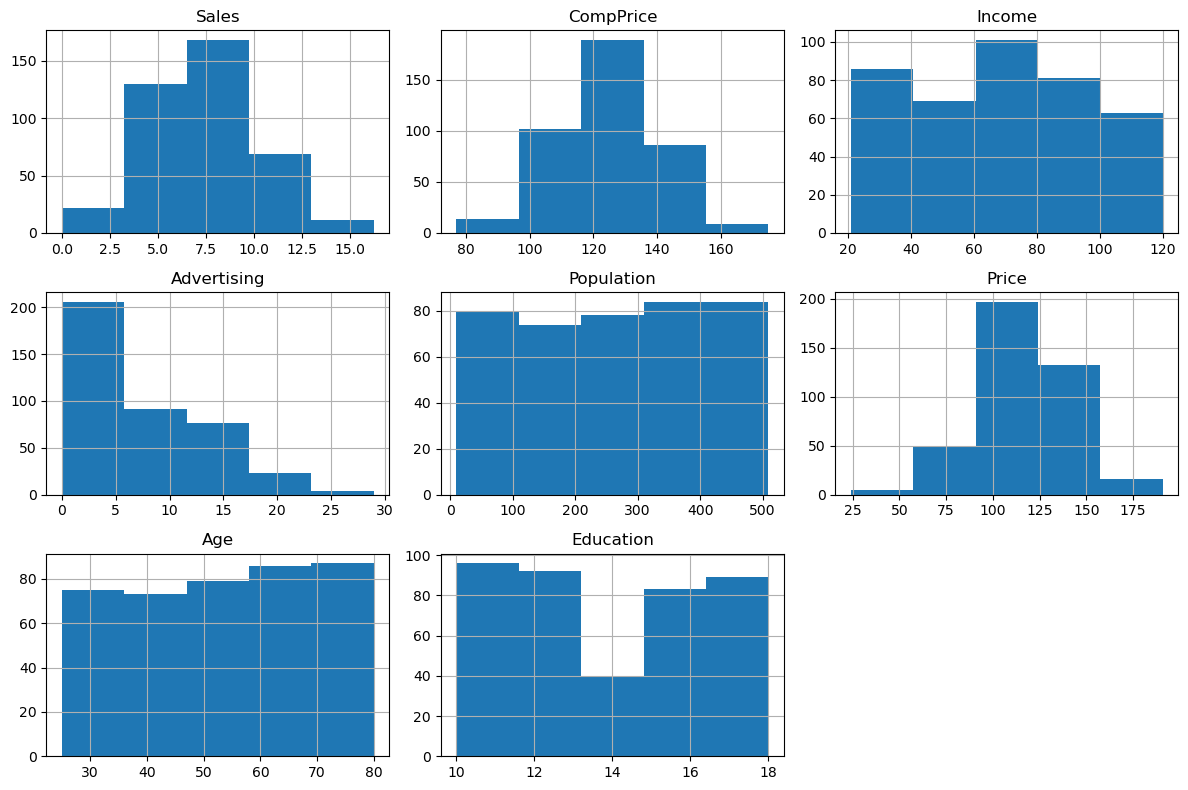

In [6]:
numeric_cols = [
    'Sales',
    'CompPrice',
    'Income',
    'Advertising',
    'Population',
    'Price',
    'Age',
    'Education'
]

df[numeric_cols].hist(figsize=(12, 8), bins=5)

plt.tight_layout()
plt.show()

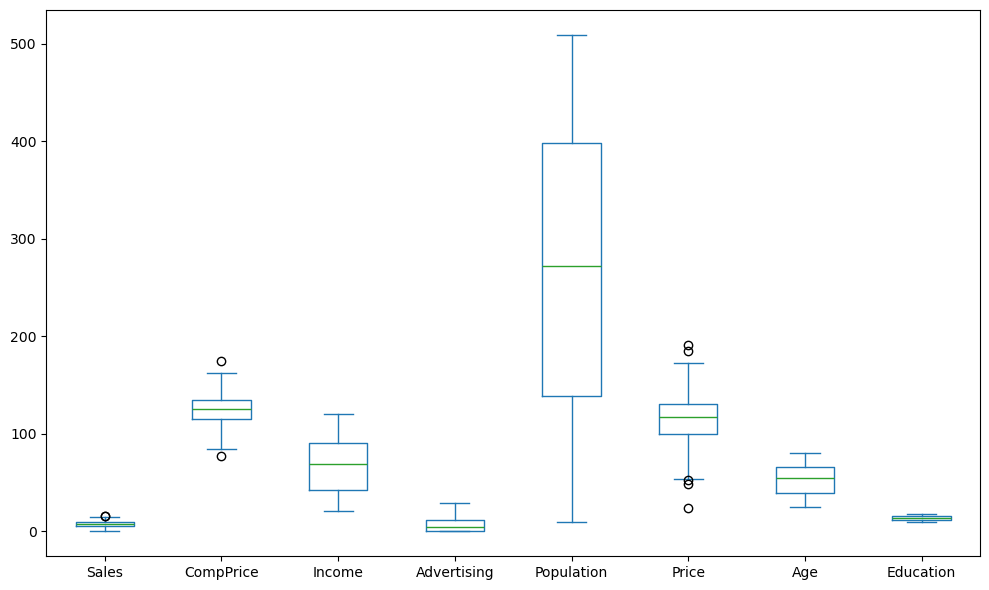

In [7]:
df[numeric_cols].plot(
    kind="box",
    figsize=(10, 6)
)

plt.tight_layout()
plt.show()

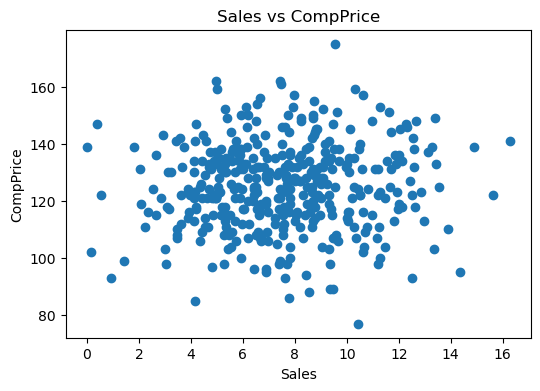

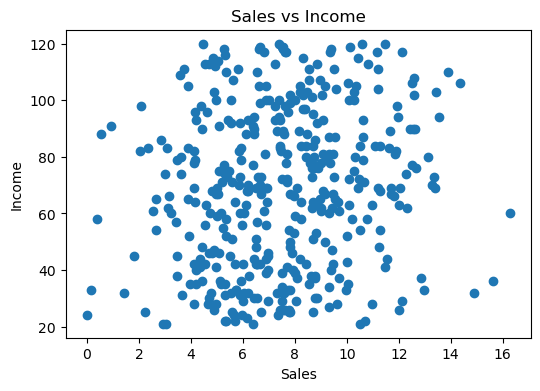

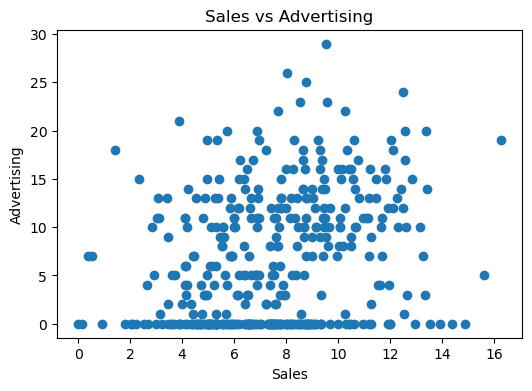

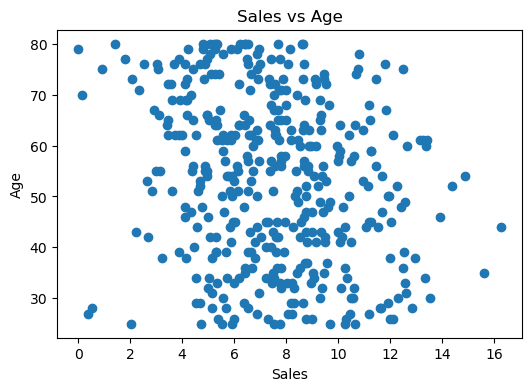

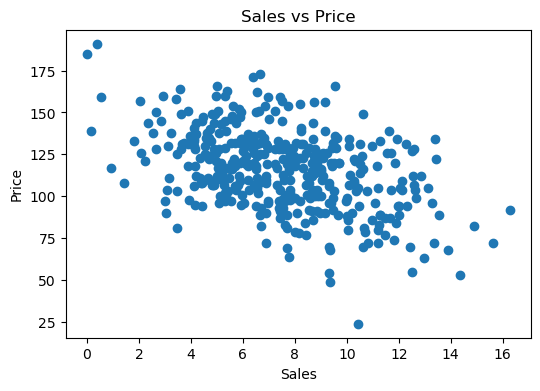

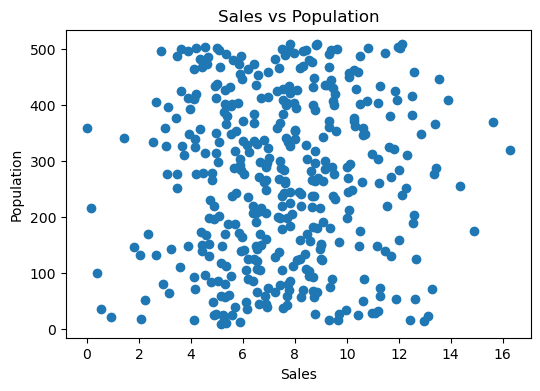

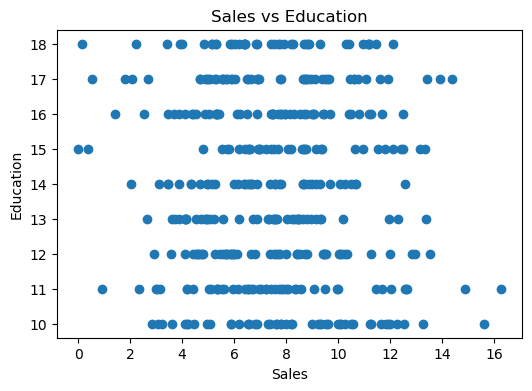

In [8]:
for column in [
    'CompPrice',
    'Income',
    'Advertising',
    'Age',
    'Price',
    'Population',
    'Education'
]:
    plt.figure(figsize=(6, 4))
    plt.scatter(df['Sales'], df[column])
    plt.xlabel('Sales')
    plt.ylabel(column)
    plt.title(f'Sales vs {column}')
    plt.show()

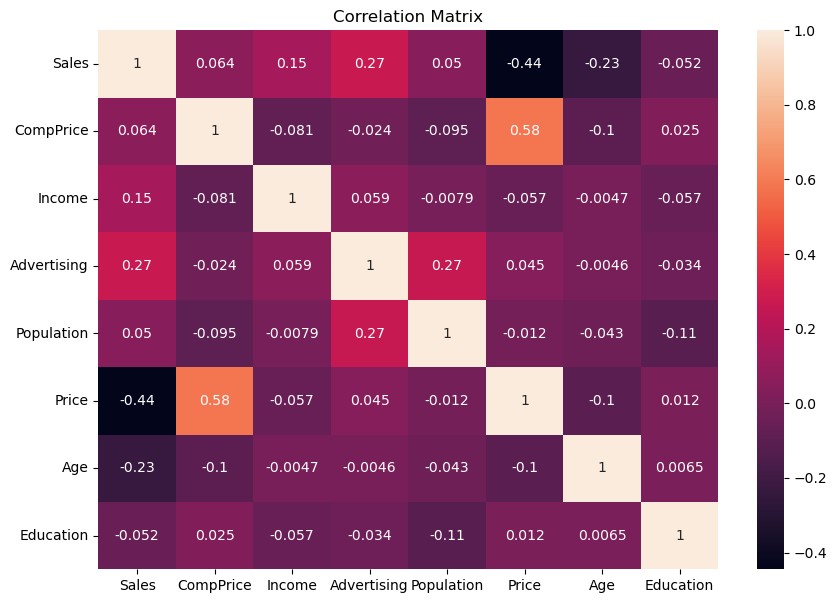

In [9]:
cor_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    cor_matrix,
    annot=True
)

plt.title("Correlation Matrix")
plt.show()

# 3. Separate Numerical and Categorical Variables

In [10]:
df_cont = df.drop(df.columns[[0, 7, 10, 11]], axis = 1)

To drop categorical columns

In [11]:
df_cont = df[
    [
        'Sales',
        'CompPrice',
        'Income',
        'Advertising',
        'Population',
        'Price',
        'Age',
        'Education'
    ]
].copy()

df_cont.head()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
0,9.50,138,73,11,276,120,42,17
1,11.22,111,48,16,260,83,65,10
2,10.06,113,35,10,269,80,59,12
3,7.40,117,100,4,466,97,55,14
4,4.15,141,64,3,340,128,38,13


# 4. Standardization using StandardScaler

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
ss = StandardScaler()

In [14]:
ss_x = ss.fit_transform(df_cont)

In [15]:
ss_x = pd.DataFrame(
    ss_x,
    columns=df_cont.columns
)

ss_x.head()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
0,0.710376,0.850455,0.155361,0.657177,0.075819,0.177823,-0.699782,1.184449
1,1.320179,-0.912484,-0.739060,1.409957,-0.032882,-1.386854,0.721723,-1.490113
2,0.908917,-0.781896,-1.204159,0.506621,0.028262,-1.513719,0.350895,-0.725953
3,-0.034151,-0.520720,1.121336,-0.396715,1.366649,-0.794814,0.103677,0.038208
4,-1.186395,1.046337,-0.166631,-0.547271,0.510625,0.516132,-0.947000,-0.343872


# 5. Normalization using MinMaxScaler

In [16]:
from sklearn.preprocessing import MinMaxScaler

In [17]:
mms = MinMaxScaler()

In [18]:
mms_x = mms.fit_transform(df_cont)

In [19]:
mms_x = pd.DataFrame(
    mms_x,
    columns=df_cont.columns
)

mms_x.head()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
0,0.583897,0.622449,0.525253,0.379310,0.533066,0.574850,0.309091,0.875
1,0.689613,0.346939,0.272727,0.551724,0.501002,0.353293,0.727273,0.000
2,0.618316,0.367347,0.141414,0.344828,0.519038,0.335329,0.618182,0.250
3,0.454825,0.408163,0.797980,0.137931,0.913828,0.437126,0.545455,0.500
4,0.255071,0.653061,0.434343,0.103448,0.661323,0.622754,0.236364,0.375


# 6. Label Encoding

In [20]:
df_cat = df[
    ['ShelveLoc', 'Urban', 'US']
].copy()

df_cat.head()

,ShelveLoc,Urban,US
0,Bad,Yes,Yes
1,Good,Yes,Yes
2,Medium,Yes,Yes
3,Medium,Yes,Yes
4,Bad,Yes,No


In [21]:
from sklearn.preprocessing import LabelEncoder

In [22]:
LE = LabelEncoder()

In [23]:
df_cat['ShelveLoc'] = LE.fit_transform(df_cat['ShelveLoc'])
df_cat['Urban'] = LE.fit_transform(df_cat['Urban'])
df_cat['US'] = LE.fit_transform(df_cat['US'])

df_cat.head()

,ShelveLoc,Urban,US
0,0,1,1
1,1,1,1
2,2,1,1
3,2,1,1
4,0,1,0


In [24]:
df_final = pd.concat(
    [ss_x, df_cat],
    axis=1
)

df_final.head()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc,Urban,US
0,0.710376,0.850455,0.155361,0.657177,0.075819,0.177823,-0.699782,1.184449,0,1,1
1,1.320179,-0.912484,-0.739060,1.409957,-0.032882,-1.386854,0.721723,-1.490113,1,1,1
2,0.908917,-0.781896,-1.204159,0.506621,0.028262,-1.513719,0.350895,-0.725953,2,1,1
3,-0.034151,-0.520720,1.121336,-0.396715,1.366649,-0.794814,0.103677,0.038208,2,1,1
4,-1.186395,1.046337,-0.166631,-0.547271,0.510625,0.516132,-0.947000,-0.343872,0,1,0


# One Hot Encoding

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("Dataset_One_Hot.csv")
df.head()

,Student_ID,Gender,City,Course,Marks,Passed
0,101,Male,Mumbai,Python,90,Yes
1,102,Female,Pune,Java,29,No
2,103,Male,Nagpur,C++,95,Yes
3,104,Female,Mumbai,Python,80,Yes
4,105,Male,Pune,Java,28,No


In [38]:
df.dtypes

Student_ID     int64
Gender        object
City          object
Course        object
Marks          int64
Passed        object
dtype: object

In [39]:
df.columns

Index(['Student_ID', 'Gender', 'City', 'Course', 'Marks', 'Passed'], dtype='object')

In [40]:
from sklearn.preprocessing import OneHotEncoder

In [41]:
ohe = OneHotEncoder()

In [42]:
categorical_cols = [
    'Gender',
    'City',
    'Course',
    'Passed'
]

data = df[categorical_cols].copy()

data.head()

,Gender,City,Course,Passed
0,Male,Mumbai,Python,Yes
1,Female,Pune,Java,No
2,Male,Nagpur,C++,Yes
3,Female,Mumbai,Python,Yes
4,Male,Pune,Java,No


In [43]:
e_data = ohe.fit_transform(data)

In [44]:
e_data = pd.DataFrame(
    e_data.toarray(),
    columns=ohe.get_feature_names_out(categorical_cols)
)
e_data.head()

,Gender_Female,Gender_Male,City_Aurangabad,City_Mumbai,City_Nagpur,City_Pune,Course_C++,Course_Java,Course_Python,Passed_No,Passed_Yes
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [49]:
numeric_data = df.drop(
    categorical_cols,
    axis=1
).copy()

df_final = pd.concat(
    [numeric_data, e_data],
    axis=1
)

df_final.head()

,Student_ID,Marks,Gender_Female,Gender_Male,City_Aurangabad,City_Mumbai,City_Nagpur,City_Pune,Course_C++,Course_Java,Course_Python,Passed_No,Passed_Yes
0,101,90,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,102,29,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,103,95,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,104,80,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,105,28,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
